#Data Loading

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [4]:
import pandas as pd
df = pd.read_csv('preprocessed_athlete_events.csv')
print(df.head())

                       Name Sex   Age  Height  Weight            Team  NOC  \
0                 A Dijiang   M  24.0   180.0    80.0           China  CHN   
1                  A Lamusi   M  23.0   170.0    60.0           China  CHN   
2       Gunnar Nielsen Aaby   M  24.0    -1.0    -1.0         Denmark  DEN   
3      Edgar Lindenau Aabye   M  34.0    -1.0    -1.0  Denmark/Sweden  DEN   
4  Christine Jacoba Aaftink   F  21.0   185.0    82.0     Netherlands  NED   

     Year  Season       City          Sport                             Event  \
0  1992.0  Summer  Barcelona     Basketball       Basketball Men's Basketball   
1  2012.0  Summer     London           Judo      Judo Men's Extra-Lightweight   
2  1920.0  Summer  Antwerpen       Football           Football Men's Football   
3  1900.0  Summer      Paris     Tug-Of-War       Tug-Of-War Men's Tug-Of-War   
4  1988.0  Winter    Calgary  Speed Skating  Speed Skating Women's 500 metres   

     Medal  
0  MISSING  
1  MISSING  
2  MI

#EDA

In [5]:
print(f"Shape of df is{df.shape}")
df.describe()

Shape of df is(25083, 13)


,Age,Height,Weight,Year
count,25082.000000,25082.000000,25082.000000,25082.000000
mean,24.522566,135.424368,54.006419,1978.846982
std,8.058629,74.569258,33.029783,29.356273
min,-1.000000,-1.000000,-1.000000,1896.000000
25%,21.000000,157.000000,46.000000,1960.000000
50%,24.000000,171.000000,65.000000,1988.000000
75%,28.000000,180.000000,75.000000,2002.000000
max,84.000000,221.000000,214.000000,2016.000000


In [9]:

eda_summary = {
    "Averages (Mean)": df.mean(numeric_only=True),
    "Unique Values": df.nunique()
}
eda_summary_df = pd.DataFrame(eda_summary)
print("Basic EDA Summaries:")
print(eda_summary_df)

Basic EDA Summaries:
        Averages (Mean)  Unique Values
Age           24.522566             61
City                NaN             42
Event               NaN            678
Height       135.424368             81
Medal               NaN              4
NOC                 NaN            218
Name                NaN          13094
Season              NaN              2
Sex                 NaN              2
Sport               NaN             62
Team                NaN            490
Weight        54.006419            138
Year        1978.846982             35


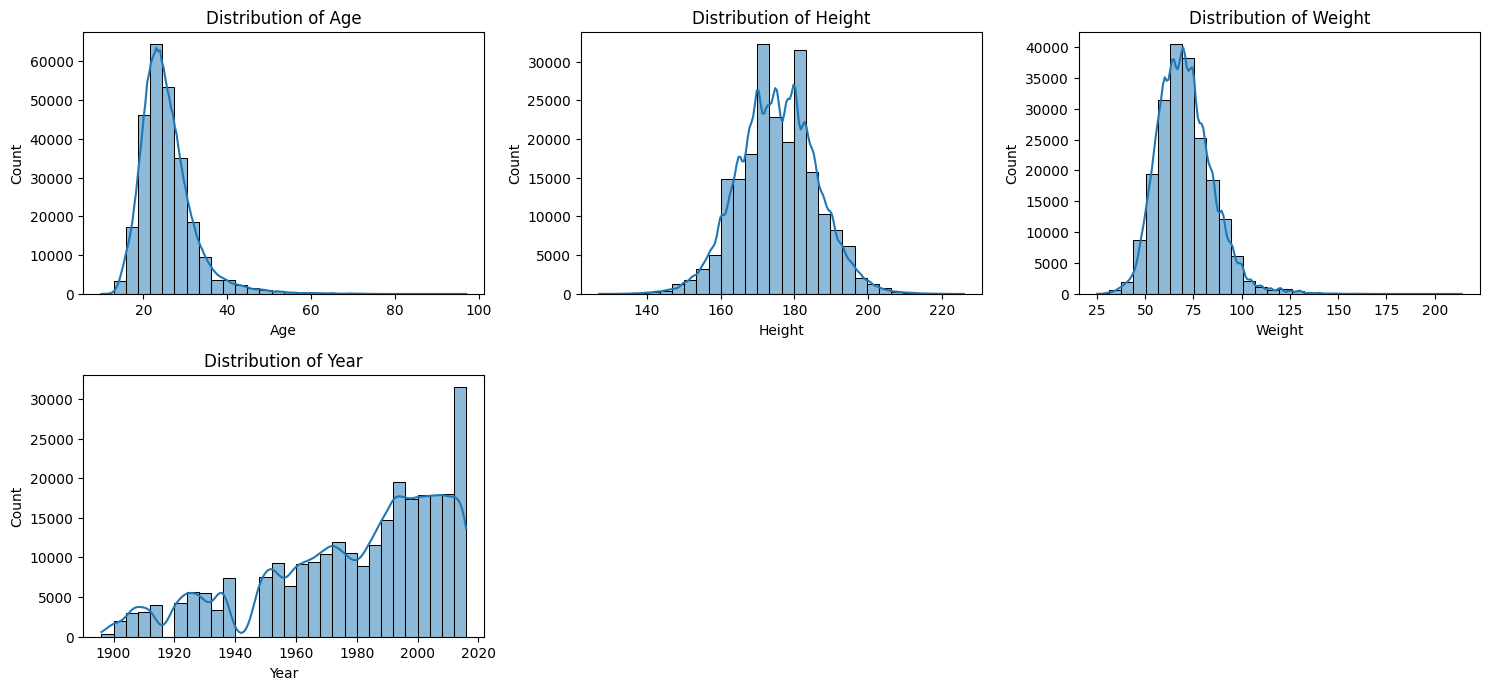

In [ ]:
# Select numeric features
numeric_features = df.select_dtypes(include=np.number)

# Create distribution plots
plt.figure(figsize=(15, 10))
for i, column in enumerate(numeric_features.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(numeric_features[column].dropna(), kde=True, bins=30)
    plt.title(f"Distribution of {column}")
plt.tight_layout()
plt.show()

In [ ]:
# Mode values and unique counts for categorical columns
categorical_modes = df.select_dtypes(include="object").mode().iloc[0]
unique_values_per_cat = df.select_dtypes(include="object").nunique()

# Create a DataFrame for categorical modes and unique values
cat_modes_df = pd.DataFrame({
    "Mode": categorical_modes,
    "Unique Values": unique_values_per_cat
})
print("Categorical Modes and Unique Values:")
print(cat_modes_df)


Categorical Modes and Unique Values:
                           Mode  Unique Values
Name       Robert Tait McKenzie         134732
Sex                           M              2
Team              United States           1184
NOC                         USA            230
Season                   Summer              2
City                     London             42
Sport                 Athletics             66
Event   Football Men's Football            765
Medal                      Gold              3


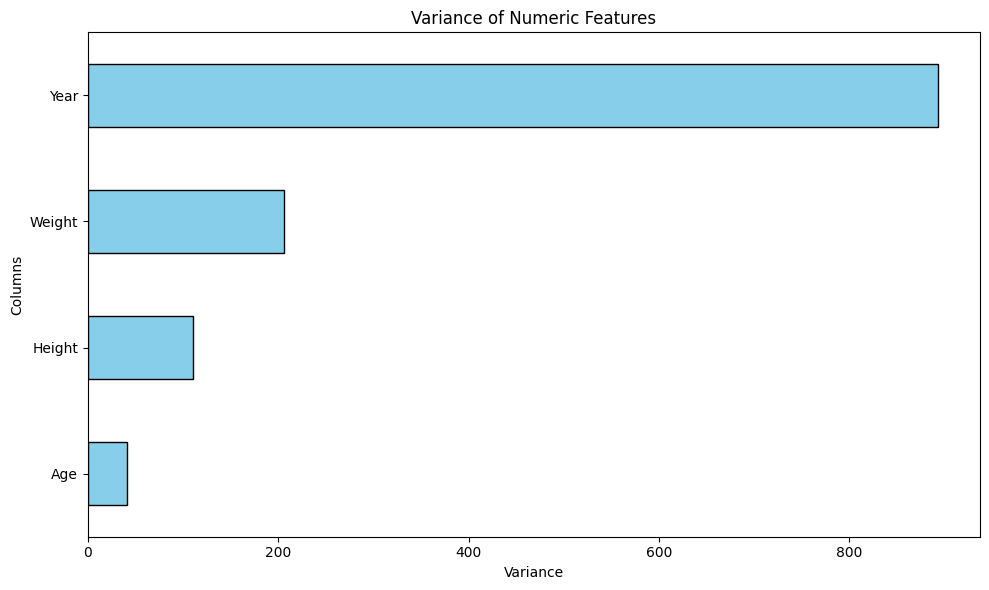

In [ ]:
# Compute variances
variances = df.var(numeric_only=True)

# Plot variances
plt.figure(figsize=(10, 6))
variances.sort_values().plot(kind="barh", color="skyblue", edgecolor="black")
plt.title("Variance of Numeric Features")
plt.xlabel("Variance")
plt.ylabel("Columns")
plt.tight_layout()
plt.show()


##Visualization